# Paso 1 — Generación de dataset sintético para kajve

**Proyecto:** Microservicio ML — Detección de anomalías en el secado del café  
**Sistema:** kajve (Monitoreo inteligente de osiles)  
**Objetivo:** Crear datos sintéticos alineados al esquema PostgreSQL del proyecto, con:

- **90 %** lecturas normales (rangos del documento de Calidad del Café)
- **10 %** anomalías inyectadas (temperatura alta, humedad crítica, patrones atípicos)
- **Valores nulos** simulando fallos de sensor o transmisión incompleta
- **Gráficas exploratorias** para validar la distribución

> **Nota sobre el esquema:** La tabla `lecturas_ambientales` almacena `temperatura` (°C) y `humedad` (% HR ambiental, sensor BME280).  
> En la documentación de dominio existen más sensores (grano, viento, lluvia, luz); cuando el esquema se amplíe, este notebook se actualizará.  
> Por ahora generamos las columnas **exactas** de las tablas BD relevantes para ML.

## 1. Configuración y rangos del dominio

Fuente: *Documento de Calidad del Café y Reglas del Dominio — kajve*

In [1]:
import uuid
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Rutas
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

RNG = np.random.default_rng(42)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

# Parámetros de generación
N_USUARIOS = 4          # 3 productores + 1 admin
N_SENSORES = 4
N_LOTES = 4             # 1 por tipo de proceso
INTERVALO_MIN = 10        # minutos entre lecturas
DIAS_SECADO = 8           # duración simulada por lote
FRAC_ANOMALIA = 0.10      # 10 % anomalías
FRAC_NULOS = 0.03         # 3 % valores faltantes en lecturas

# Rangos NORMALES — humedad relativa ambiental (BME280)
HR_IDEAL = (35.0, 65.0)
HR_ADVERTENCIA = (65.0, 80.0)

# Rangos NORMALES — temperatura según proceso (°C)
TEMP_NORMAL = {
    'lavado': (18.0, 35.0),
    'honey': (20.0, 35.0),
    'natural': (20.0, 40.0),
}

# Umbrales CRÍTICOS para inyectar anomalías
TEMP_CRITICA = {
    'lavado': (40.0, 44.0),
    'honey': (40.0, 43.0),
    'natural': (45.0, 48.0),
}
HR_CRITICA = (88.0, 98.0)
HR_RIESGO = (80.0, 90.0)

TIPOS_ANOMALIA = [
    'temperatura_alta',
    'humedad_ambiental_alta',
    'humedad_critica',
    'fluctuacion_termica',
    'valor_imposible',
    'lectura_estancada',
]

print(f'Directorio de salida: {RAW_DIR}')

Directorio de salida: D:\9 - cuatri\microservicioMLL\data\raw


## 2. Tablas dimensionales (usuarios, sensores, lotes_cafe, modelos_ml)

Columnas **exactas** del script SQL de la BD.

In [2]:
base_fecha = datetime(2026, 6, 1, 6, 0, 0)

# --- usuarios ---
usuarios_rows = [
    {
        'id_usuario': 1,
        'nombre': 'Carlos Méndez López',
        'email': 'carlos.mendez@kajve.mx',
        'password_hash': '$2b$12$ejemplo_hash_admin',
        'rol': 'administrador',
        'telefono': '9611234567',
        'estado': 'activo',
        'fecha_registro': base_fecha - timedelta(days=120),
    },
    {
        'id_usuario': 2,
        'nombre': 'María Santiz Pérez',
        'email': 'maria.santiz@kajve.mx',
        'password_hash': '$2b$12$ejemplo_hash_prod1',
        'rol': 'productor',
        'telefono': '9612345678',
        'estado': 'activo',
        'fecha_registro': base_fecha - timedelta(days=90),
    },
    {
        'id_usuario': 3,
        'nombre': 'Juan Hernández Ruiz',
        'email': 'juan.hernandez@kajve.mx',
        'password_hash': '$2b$12$ejemplo_hash_prod2',
        'rol': 'productor',
        'telefono': '9613456789',
        'estado': 'activo',
        'fecha_registro': base_fecha - timedelta(days=60),
    },
    {
        'id_usuario': 4,
        'nombre': 'Ana López Gómez',
        'email': 'ana.lopez@kajve.mx',
        'password_hash': '$2b$12$ejemplo_hash_prod3',
        'rol': 'productor',
        'telefono': '9614567890',
        'estado': 'activo',
        'fecha_registro': base_fecha - timedelta(days=30),
    },
]
df_usuarios = pd.DataFrame(usuarios_rows)

# --- sensores ---
modelos_sensor = ['BME280+DS18B20', 'BME280+DS18B20', 'BME280+DS18B20', 'BME280+DS18B20']
sensores_rows = []
for i in range(1, N_SENSORES + 1):
    mac = ':'.join(f'{RNG.integers(0, 256):02x}' for _ in range(6))
    sensores_rows.append({
        'id_sensor': i,
        'mac_address': mac,
        'id_cola_mqtt': f'sensors/esp32-{i:03d}/data',
        'provisioning_token': str(uuid.uuid4()),
        'token_usado': True,
        'tipo': 'ambos',
        'modelo': modelos_sensor[i - 1],
        'estado': 'activo',
        'fecha_registro': base_fecha - timedelta(days=100 + i * 5),
        'ultima_conexion': base_fecha + timedelta(days=DIAS_SECADO),
    })
df_sensores = pd.DataFrame(sensores_rows)

# --- lotes_cafe ---
procesos = [
    ('Lote Lavado Jun-2026', 'Arabica Lavado', 'lavado', 2, 1, 320.0),
    ('Lote Honey Jun-2026', 'Arabica Honey', 'honey', 3, 2, 280.5),
    ('Lote Natural Jun-2026', 'Typica Natural', 'natural', 4, 3, 350.0),
    ('Lote Lavado Altura', 'Geisha Lavado', 'lavado', 2, 4, 150.0),
]
lotes_rows = []
for idx, (nombre, variedad, proceso, id_usuario, id_sensor, peso) in enumerate(procesos, start=1):
    inicio = base_fecha + timedelta(days=(idx - 1) * 2)
    lotes_rows.append({
        'id_lote': idx,
        'id_usuario': id_usuario,
        'id_sensor': id_sensor,
        'nombre_lote': nombre,
        'variedad': variedad,
        'peso_kg': peso,
        'ubicacion': f'Finca El Osil #{idx}, Chiapas',
        'codigo_qr': f'KAJVE-QR-{idx:04d}-{uuid.uuid4().hex[:8]}',
        'estado': 'en_proceso',
        'fecha_inicio_secado': inicio,
        'fecha_fin_secado': None,
        'linked_at': inicio - timedelta(hours=2),
        'created_at': inicio - timedelta(days=1),
        '_tipo_proceso': proceso,  # metadato para generación (no va a BD)
    })
df_lotes = pd.DataFrame(lotes_rows)
tipo_proceso_map = df_lotes.set_index('id_lote')['_tipo_proceso'].to_dict()

# --- modelos_ml ---
df_modelos_ml = pd.DataFrame([
    {
        'id_modelo': 1,
        'nombre': 'IsolationForest Anomalias Secado',
        'version': '1.0.0',
        'tipo': 'anomalia',
        'rmse': None,
        'activo': True,
        'fecha_entrenamiento': base_fecha,
    }
])

print('Usuarios:', len(df_usuarios))
print('Sensores:', len(df_sensores))
print('Lotes:', len(df_lotes))
df_lotes[['id_lote', 'nombre_lote', 'variedad', '_tipo_proceso', 'peso_kg']]

Usuarios: 4
Sensores: 4
Lotes: 4


,id_lote,nombre_lote,variedad,_tipo_proceso,peso_kg
0,1,Lote Lavado Jun-2026,Arabica Lavado,lavado,320.0
1,2,Lote Honey Jun-2026,Arabica Honey,honey,280.5
2,3,Lote Natural Jun-2026,Typica Natural,natural,350.0
3,4,Lote Lavado Altura,Geisha Lavado,lavado,150.0


## 3. Generación de lecturas_ambientales (serie temporal)

Simulamos el ciclo de secado con variación diurna (sol/noche) y degradación gradual de condiciones.

- **Normal (90 %):** temperatura y humedad dentro de rangos ideales del dominio.
- **Anomalía (10 %):** inyectada sobre lecturas existentes con tipos definidos en las reglas de alerta.

In [3]:
def variacion_diurna(minutos_desde_inicio: int, amplitud: float) -> float:
    """Onda sinusoidal para simular ciclo día/noche en el osil."""
    horas = minutos_desde_inicio / 60.0
    return amplitud * np.sin(2 * np.pi * horas / 24.0)


def generar_lectura_normal(proceso: str, minutos: int, progreso: float) -> tuple[float, float]:
    """Genera temperatura y humedad normales según tipo de proceso."""
    t_min, t_max = TEMP_NORMAL[proceso]
    centro_temp = (t_min + t_max) / 2
    temp = centro_temp + variacion_diurna(minutos, amplitud=4.0) + RNG.normal(0, 0.8)
    temp = float(np.clip(temp, t_min, t_max))

    # Humedad baja levemente conforme avanza el secado (proxy ambiental)
    hr_base = HR_IDEAL[1] - progreso * 12.0
    humedad = hr_base + variacion_diurna(minutos, amplitud=5.0) + RNG.normal(0, 2.0)
    humedad = float(np.clip(humedad, HR_IDEAL[0], HR_IDEAL[1]))
    return round(temp, 2), round(humedad, 2)


def inyectar_anomalia(
    proceso: str, temp: float, humedad: float, tipo: str
) -> tuple[float, float, str]:
    """Modifica una lectura normal para convertirla en anomalía."""
    if tipo == 'temperatura_alta':
        lo, hi = TEMP_CRITICA[proceso]
        temp = float(RNG.uniform(lo, hi))
    elif tipo == 'humedad_ambiental_alta':
        humedad = float(RNG.uniform(*HR_RIESGO))
    elif tipo == 'humedad_critica':
        humedad = float(RNG.uniform(*HR_CRITICA))
    elif tipo == 'fluctuacion_termica':
        temp = temp + float(RNG.choice([-1, 1]) * RNG.uniform(12, 18))
    elif tipo == 'valor_imposible':
        if RNG.random() < 0.5:
            temp = float(RNG.uniform(85, 120))  # fuera de rango físico DS18B20 útil
        else:
            humedad = float(RNG.uniform(-5, 5))  # HR imposible
    elif tipo == 'lectura_estancada':
        # Se maneja en el loop: repetir valor anterior (simula sensor pegado)
        pass
    return round(temp, 2), round(humedad, 2), tipo


lecturas = []
id_lectura = 1
total_lecturas = 0

for _, lote in df_lotes.iterrows():
    id_lote = int(lote['id_lote'])
    id_sensor = int(lote['id_sensor'])
    proceso = lote['_tipo_proceso']
    inicio = lote['fecha_inicio_secado']
    n_lecturas = int(DIAS_SECADO * 24 * 60 / INTERVALO_MIN)
    total_lecturas += n_lecturas

    n_anomalias_lote = int(round(n_lecturas * FRAC_ANOMALIA))
    indices_anomalia = set(RNG.choice(n_lecturas, size=n_anomalias_lote, replace=False))

    ultima_temp, ultima_hr = None, None

    for i in range(n_lecturas):
        minutos = i * INTERVALO_MIN
        ts = inicio + timedelta(minutes=minutos)
        progreso = i / max(n_lecturas - 1, 1)

        temp, humedad = generar_lectura_normal(proceso, minutos, progreso)
        es_anomalia = i in indices_anomalia
        tipo_anomalia = None

        if es_anomalia:
            tipo = TIPOS_ANOMALIA[int(RNG.integers(0, len(TIPOS_ANOMALIA)))]
            if tipo == 'lectura_estancada' and ultima_temp is not None:
                temp, humedad = ultima_temp, ultima_hr
                tipo_anomalia = tipo
            else:
                temp, humedad, tipo_anomalia = inyectar_anomalia(proceso, temp, humedad, tipo)

        ultima_temp, ultima_hr = temp, humedad

        lecturas.append({
            'id_lectura': id_lectura,
            'id_sensor': id_sensor,
            'id_lote': id_lote,
            'temperatura': temp,
            'humedad': humedad,
            'timestamp': ts,
            '_tipo_proceso': proceso,
            '_es_anomalia': es_anomalia,
            '_tipo_anomalia': tipo_anomalia,
        })
        id_lectura += 1

df_lecturas = pd.DataFrame(lecturas)
pct_anom = df_lecturas['_es_anomalia'].mean() * 100
print(f'Total lecturas generadas: {len(df_lecturas):,}')
print(f'Anomalías: {df_lecturas["_es_anomalia"].sum():,} ({pct_anom:.1f} %)')
print(f'Normal: {(~df_lecturas["_es_anomalia"]).sum():,} ({100 - pct_anom:.1f} %)')
df_lecturas.head(8)

Total lecturas generadas: 4,608
Anomalías: 460 (10.0 %)
Normal: 4,148 (90.0 %)


,id_lectura,id_sensor,id_lote,temperatura,humedad,timestamp,_tipo_proceso,_es_anomalia,_tipo_anomalia
0,1,1,1,26.79,65.00,2026-06-01 06:00:00,lavado,False,None
1,2,1,1,25.72,63.93,2026-06-01 06:10:00,lavado,False,None
2,3,1,1,26.11,64.64,2026-06-01 06:20:00,lavado,False,None
3,4,1,1,25.92,65.00,2026-06-01 06:30:00,lavado,False,None
4,5,1,1,27.02,62.88,2026-06-01 06:40:00,lavado,False,None
5,6,1,1,26.55,65.00,2026-06-01 06:50:00,lavado,False,None
6,7,1,1,28.21,65.00,2026-06-01 07:00:00,lavado,False,None
7,8,1,1,30.03,65.00,2026-06-01 07:10:00,lavado,False,None


## 4. Inyección de valores nulos (datos vacíos)

Simula fallos intermitentes del sensor capacitivo, pérdida de paquetes MQTT o lecturas incompletas del ESP32.

In [4]:
df_lecturas_bd = df_lecturas.copy()
n_filas = len(df_lecturas_bd)
n_nulos = int(round(n_filas * FRAC_NULOS))
indices_nulos = RNG.choice(n_filas, size=n_nulos, replace=False)

for idx in indices_nulos:
    campo = 'temperatura' if RNG.random() < 0.5 else 'humedad'
    df_lecturas_bd.at[idx, campo] = np.nan
    # ~20 % de casos: ambos campos nulos (payload vacío parcial)
    if RNG.random() < 0.2:
        otro = 'humedad' if campo == 'temperatura' else 'temperatura'
        df_lecturas_bd.at[idx, otro] = np.nan

cols_bd = ['id_lectura', 'id_sensor', 'id_lote', 'temperatura', 'humedad', 'timestamp']
df_lecturas_export = df_lecturas_bd[cols_bd].copy()

nulos_temp = df_lecturas_export['temperatura'].isna().sum()
nulos_hr = df_lecturas_export['humedad'].isna().sum()
print(f'Nulos en temperatura: {nulos_temp} ({nulos_temp/n_filas*100:.2f} %)')
print(f'Nulos en humedad: {nulos_hr} ({nulos_hr/n_filas*100:.2f} %)')
df_lecturas_export[df_lecturas_export.isna().any(axis=1)].head(5)

Nulos en temperatura: 71 (1.54 %)
Nulos en humedad: 83 (1.80 %)


,id_lectura,id_sensor,id_lote,temperatura,humedad,timestamp
4,5,1,1,NaN,62.88,2026-06-01 06:40:00
16,17,1,1,NaN,65.00,2026-06-01 08:40:00
29,30,1,1,30.66,NaN,2026-06-01 10:50:00
39,40,1,1,NaN,65.00,2026-06-01 12:30:00
51,52,1,1,30.64,NaN,2026-06-01 14:30:00


## 5. Dataset de entrenamiento ML (lecturas + etiqueta de anomalía)

Archivo auxiliar para entrenar y evaluar el modelo no supervisado.  
Las columnas con prefijo `_` **no** se insertan en PostgreSQL; son metadatos de entrenamiento.

In [5]:
df_ml_training = df_lecturas[[
    'id_lectura', 'id_sensor', 'id_lote', 'temperatura', 'humedad', 'timestamp',
    '_tipo_proceso', '_es_anomalia', '_tipo_anomalia'
]].copy()

# Aplicar los mismos nulos al dataset de entrenamiento
df_ml_training['temperatura'] = df_lecturas_export['temperatura']
df_ml_training['humedad'] = df_lecturas_export['humedad']

print('Distribución de tipos de anomalía:')
print(df_ml_training.loc[df_ml_training['_es_anomalia'], '_tipo_anomalia'].value_counts())
df_ml_training.describe(include='all').T

Distribución de tipos de anomalía:
_tipo_anomalia
fluctuacion_termica       87
humedad_critica           78
lectura_estancada         77
valor_imposible           75
temperatura_alta          72
humedad_ambiental_alta    71
Name: count, dtype: int64


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id_lectura,4608.0,NaN,NaN,NaN,2304.5,1.0,1152.75,2304.5,3456.25,4608.0,1330.35935
id_sensor,4608.0,NaN,NaN,NaN,2.5,1.0,1.75,2.5,3.25,4.0,1.118155
id_lote,4608.0,NaN,NaN,NaN,2.5,1.0,1.75,2.5,3.25,4.0,1.118155
temperatura,4537.0,NaN,NaN,NaN,28.613469,5.85,24.96,27.86,30.42,119.69,8.376934
humedad,4525.0,NaN,NaN,NaN,59.077052,-4.94,55.1,59.11,63.37,97.86,8.931849
timestamp,4608,NaN,NaN,NaN,2026-06-08 05:55:00,2026-06-01 06:00:00,2026-06-05 21:57:30,2026-06-08 05:55:00,2026-06-10 13:52:30,2026-06-15 05:50:00,NaN
_tipo_proceso,4608,3,lavado,2304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
_es_anomalia,4608,2,False,4148,NaN,NaN,NaN,NaN,NaN,NaN,NaN
_tipo_anomalia,460,6,fluctuacion_termica,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Exportar CSV (columnas de BD)

Listos para importar con `COPY` / `\copy` en PostgreSQL o para consumo del microservicio.

In [6]:
# Exportar tablas dimensionales (sin columnas internas)
df_usuarios.to_csv(RAW_DIR / 'usuarios.csv', index=False)
df_sensores.to_csv(RAW_DIR / 'sensores.csv', index=False)
df_lotes.drop(columns=['_tipo_proceso']).to_csv(RAW_DIR / 'lotes_cafe.csv', index=False)
df_modelos_ml.to_csv(RAW_DIR / 'modelos_ml.csv', index=False)

# Lecturas — esquema exacto BD
df_lecturas_export.to_csv(RAW_DIR / 'lecturas_ambientales.csv', index=False)

# Dataset ML con etiquetas
df_ml_training.to_csv(RAW_DIR / 'lecturas_ml_training.csv', index=False)

print('Archivos generados:')
for f in sorted(RAW_DIR.glob('*.csv')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:30s}  {size_kb:8.1f} KB')

Archivos generados:
  lecturas_ambientales.csv           185.7 KB
  lecturas_ml_training.csv           256.1 KB
  lotes_cafe.csv                       0.8 KB
  modelos_ml.csv                       0.1 KB
  sensores.csv                         0.7 KB
  usuarios.csv                         0.5 KB


## 7. Gráficas exploratorias (EDA)

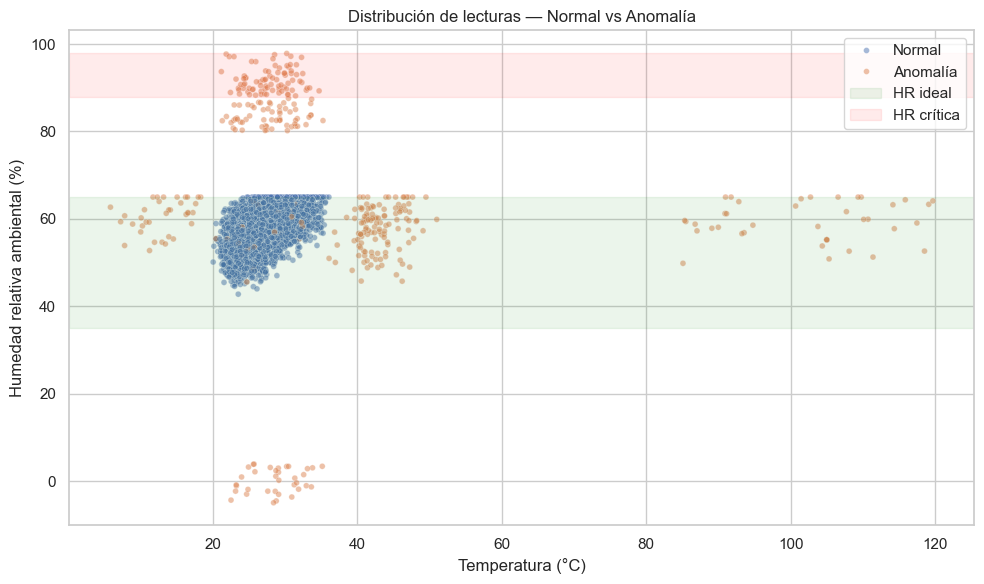

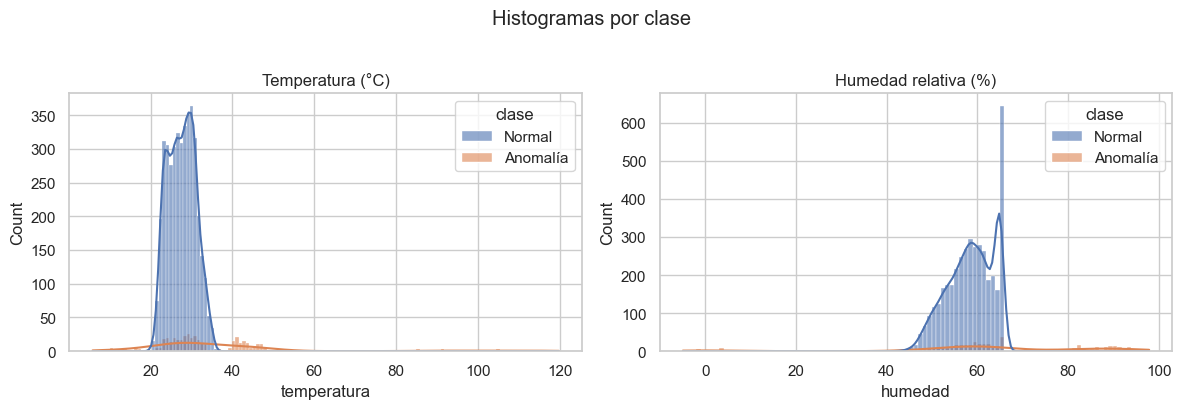

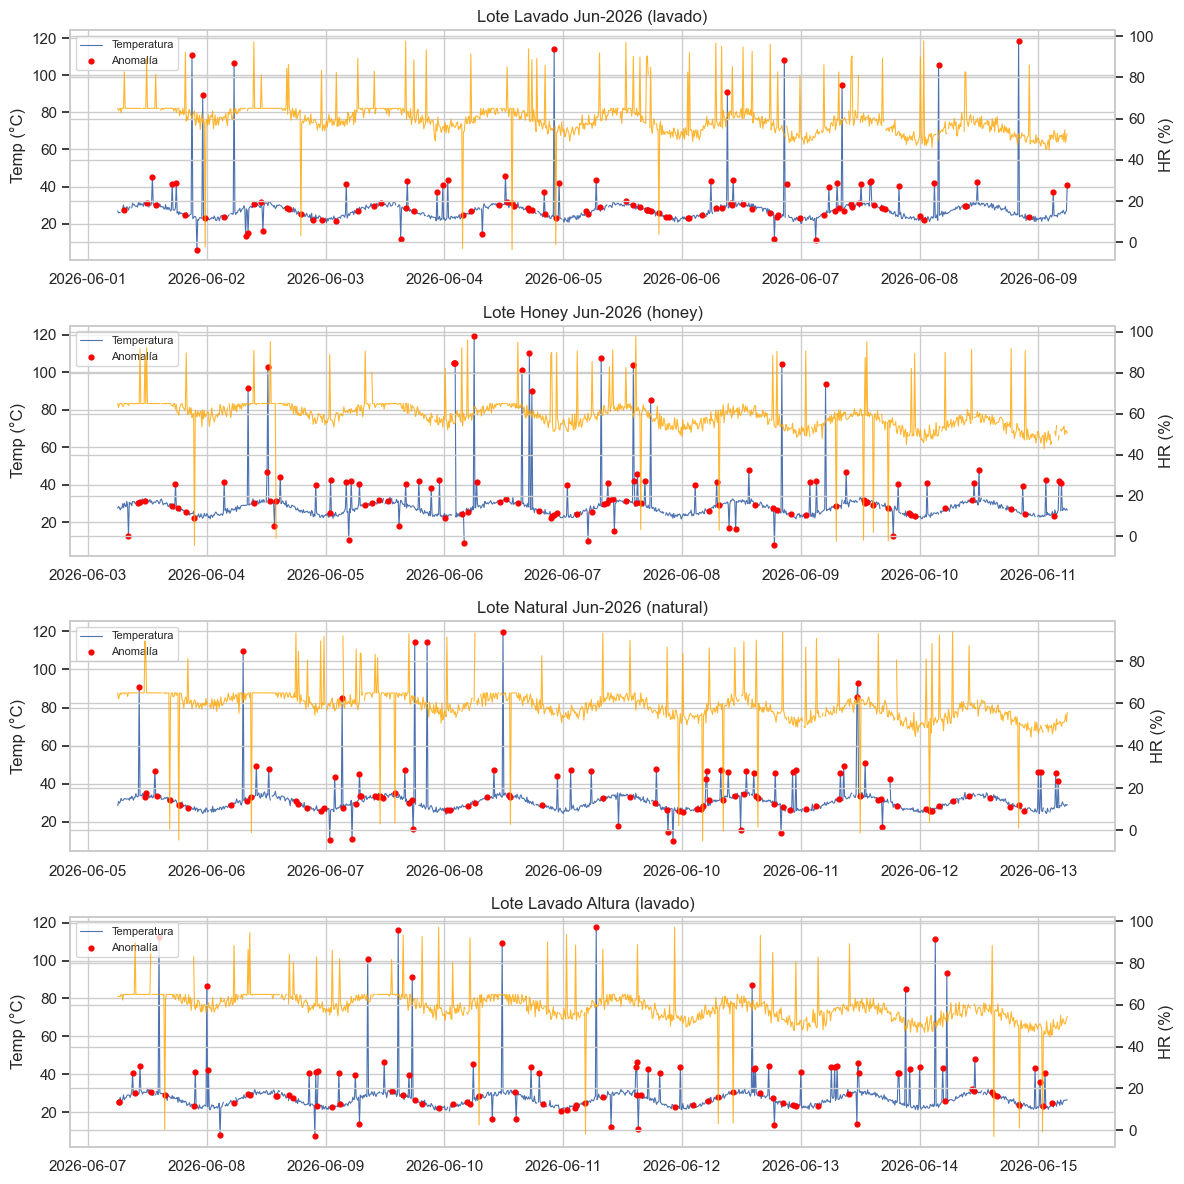

C:\Users\Alexito\AppData\Local\Temp\ipykernel_35008\1094728299.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo.index, y=conteo.values, ax=ax, palette='Reds_r')


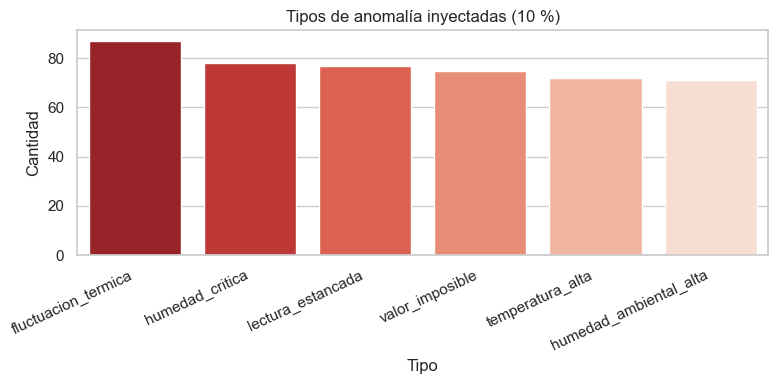

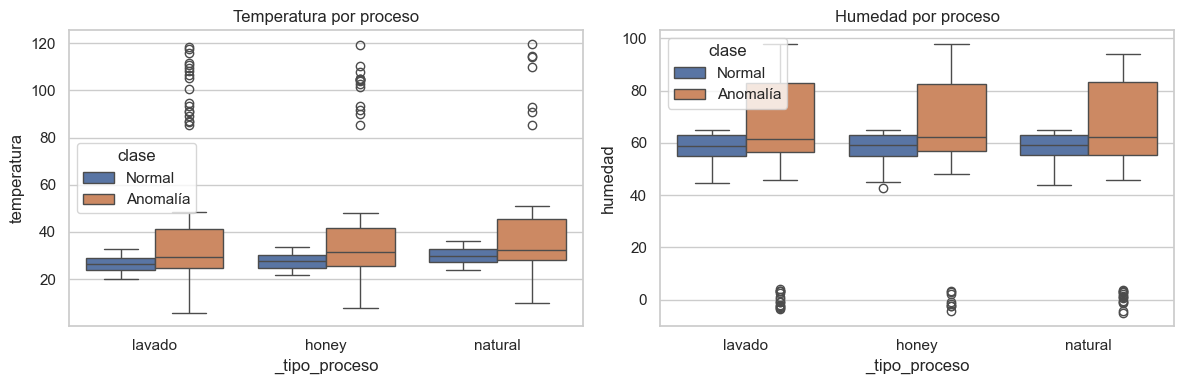

Figuras guardadas en: D:\9 - cuatri\microservicioMLL\data\figures


In [7]:
FIG_DIR = DATA_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

df_plot = df_ml_training.dropna(subset=['temperatura', 'humedad']).copy()
df_plot['clase'] = np.where(df_plot['_es_anomalia'], 'Anomalía', 'Normal')

# --- 7.1 Distribución temperatura vs humedad ---
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_plot, x='temperatura', y='humedad', hue='clase',
    alpha=0.5, s=18, ax=ax
)
ax.axhspan(HR_IDEAL[0], HR_IDEAL[1], alpha=0.08, color='green', label='HR ideal')
ax.axhspan(HR_CRITICA[0], HR_CRITICA[1], alpha=0.08, color='red', label='HR crítica')
ax.set_title('Distribución de lecturas — Normal vs Anomalía')
ax.set_xlabel('Temperatura (°C)')
ax.set_ylabel('Humedad relativa ambiental (%)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '01_scatter_temp_hr.png', dpi=150)
plt.show()

# --- 7.2 Histogramas ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, titulo in zip(
    axes,
    ['temperatura', 'humedad'],
    ['Temperatura (°C)', 'Humedad relativa (%)'],
):
    sns.histplot(data=df_plot, x=col, hue='clase', kde=True, ax=ax, alpha=0.6)
    ax.set_title(titulo)
plt.suptitle('Histogramas por clase', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '02_histogramas.png', dpi=150)
plt.show()

# --- 7.3 Serie temporal por lote ---
fig, axes = plt.subplots(len(df_lotes), 1, figsize=(12, 3 * len(df_lotes)), sharex=False)
if len(df_lotes) == 1:
    axes = [axes]

for ax, (_, lote) in zip(axes, df_lotes.iterrows()):
    id_lote = lote['id_lote']
    sub = df_ml_training[df_ml_training['id_lote'] == id_lote].copy()
    ax.plot(sub['timestamp'], sub['temperatura'], label='Temperatura', linewidth=0.8)
    ax2 = ax.twinx()
    ax2.plot(sub['timestamp'], sub['humedad'], color='orange', label='Humedad', linewidth=0.8, alpha=0.8)
    anom = sub[sub['_es_anomalia']]
    ax.scatter(anom['timestamp'], anom['temperatura'], color='red', s=12, zorder=5, label='Anomalía')
    ax.set_title(f"{lote['nombre_lote']} ({lote['_tipo_proceso']})")
    ax.set_ylabel('Temp (°C)')
    ax2.set_ylabel('HR (%)')
    ax.legend(loc='upper left', fontsize=8)

plt.xlabel('Timestamp')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_series_temporales.png', dpi=150)
plt.show()

# --- 7.4 Tipos de anomalía ---
fig, ax = plt.subplots(figsize=(8, 4))
conteo = df_ml_training.loc[df_ml_training['_es_anomalia'], '_tipo_anomalia'].value_counts()
sns.barplot(x=conteo.index, y=conteo.values, ax=ax, palette='Reds_r')
ax.set_title('Tipos de anomalía inyectadas (10 %)')
ax.set_xlabel('Tipo')
ax.set_ylabel('Cantidad')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_tipos_anomalia.png', dpi=150)
plt.show()

# --- 7.5 Boxplot por tipo de proceso ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_plot, x='_tipo_proceso', y='temperatura', hue='clase', ax=axes[0])
axes[0].set_title('Temperatura por proceso')
sns.boxplot(data=df_plot, x='_tipo_proceso', y='humedad', hue='clase', ax=axes[1])
axes[1].set_title('Humedad por proceso')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_boxplot_proceso.png', dpi=150)
plt.show()

print(f'Figuras guardadas en: {FIG_DIR}')

## 8. Resumen y validación de rangos

Verificamos que los datos normales caen dentro de los rangos del dominio kajve.

In [8]:
normales = df_ml_training[(~df_ml_training['_es_anomalia']) & df_ml_training['temperatura'].notna()]

resumen = []
for proceso in ['lavado', 'honey', 'natural']:
    sub = normales[normales['_tipo_proceso'] == proceso]
    t_min, t_max = TEMP_NORMAL[proceso]
    resumen.append({
        'proceso': proceso,
        'n_lecturas': len(sub),
        'temp_min': sub['temperatura'].min(),
        'temp_max': sub['temperatura'].max(),
        'temp_rango_esperado': f'{t_min}–{t_max}',
        'hr_min': sub['humedad'].min(),
        'hr_max': sub['humedad'].max(),
        'hr_rango_esperado': f'{HR_IDEAL[0]}–{HR_IDEAL[1]}',
    })

df_resumen = pd.DataFrame(resumen)
display(df_resumen)

print('\n=== CHECKLIST PASO 1 ===')
checks = [
    ('90/10 normal/anomalía', abs(df_ml_training['_es_anomalia'].mean() - 0.10) < 0.015),
    ('Valores nulos presentes', df_lecturas_export.isna().any().any()),
    ('4 lotes (lavado/honey/natural)', df_lotes['_tipo_proceso'].nunique() >= 3),
    ('CSV exportados', (RAW_DIR / 'lecturas_ambientales.csv').exists()),
    ('Figuras generadas', (FIG_DIR / '01_scatter_temp_hr.png').exists()),
]
for nombre, ok in checks:
    print(f"  [{'OK' if ok else 'FAIL'}] {nombre}")

,proceso,n_lecturas,temp_min,temp_max,temp_rango_esperado,hr_min,hr_max,hr_rango_esperado
0,lavado,2046,20.07,32.63,18.0–35.0,44.58,65.0,35.0–65.0
1,honey,1019,21.71,33.68,20.0–35.0,42.78,65.0,35.0–65.0
2,natural,1018,23.93,36.09,20.0–40.0,44.00,65.0,35.0–65.0



=== CHECKLIST PASO 1 ===
  [OK] 90/10 normal/anomalía
  [OK] Valores nulos presentes
  [OK] 4 lotes (lavado/honey/natural)
  [OK] CSV exportados
  [OK] Figuras generadas


## 9. Próximo paso (Paso 2)

1. Imputar o filtrar nulos en el pipeline de preprocesamiento.
2. Entrenar **Isolation Forest** con `lecturas_ml_training.csv` (solo filas completas).
3. Evaluar recall sobre las anomalías inyectadas (`_es_anomalia`).
4. Exponer inferencia vía FastAPI (`POST /anomalies/detect`).

---

### Script SQL para cargar datos (referencia)

```sql
\copy usuarios FROM 'data/raw/usuarios.csv' CSV HEADER;
\copy sensores FROM 'data/raw/sensores.csv' CSV HEADER;
\copy lotes_cafe FROM 'data/raw/lotes_cafe.csv' CSV HEADER;
\copy lecturas_ambientales FROM 'data/raw/lecturas_ambientales.csv' CSV HEADER;
\copy modelos_ml FROM 'data/raw/modelos_ml.csv' CSV HEADER;
```

> Ajustar secuencias SERIAL después del COPY:
> `SELECT setval('usuarios_id_usuario_seq', (SELECT MAX(id_usuario) FROM usuarios));`